<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Mercedes%20Benz%20Stock%20Data_(1996_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mercedes-Benz Stock Data (1996-2026)


##  Understanding Mercedes-Benz Stock: A Data-Driven Journey
This analysis delved deep into Mercedes-Benz stock data spanning from 1996 to early 2026, encompassing over 7,500 daily trading observations. The initial exploration confirmed a clean dataset with no missing values or duplicates, providing a robust foundation for further investigation. We examined various aspects of the stock's behavior, from its fundamental statistical properties to advanced time-series characteristics and the performance of machine learning models designed to predict its movements.

Key Statistical Insights:
One of the most striking findings from the statistical analysis was that Mercedes-Benz's daily returns do not follow a normal distribution. The Jarque-Bera test strongly rejected normality, revealing the presence of "fat tails" (leptokurtosis). This is a critical insight for investors: extreme market events, such as significant price drops or surges, occur far more frequently than traditional, normally-distributed models would predict. Therefore, relying solely on standard deviation could severely underestimate potential risks. Despite these extreme movements, the stock's daily returns were found to be stationary, implying that its volatility profile, while prone to large swings, is mean-reverting over time – market panics eventually cool, and euphoric rallies eventually revert to a historical baseline.

To quantify this risk, we calculated historical Value at Risk (VaR) and Conditional VaR (CVaR). The 99% VaR indicated that on 99 out of 100 trading days, Mercedes-Benz would not drop more than approximately 6.19%. However, for those rare, severe days when VaR is breached (true market crashes), the 99% CVaR showed an average expected drop of about 8.10%, highlighting the magnitude of tail risk.

Time-Series Dynamics and Algorithmic Signals:
Delving into time-series analysis, we observed that algorithmic momentum indicators provide valuable insights. Macro-trends were identified using 50-day and 200-day Simple Moving Average (SMA) crossovers, revealing periods of bullish and bearish market regimes. Bollinger Bands, charting price volatility within two standard deviations of a 20-day SMA, helped identify mathematically "overbought" and "oversold" conditions. Oscillators like the Relative Strength Index (RSI) and Moving Average Convergence Divergence (MACD) provided further short-term trading signals.

Critically, the data exhibited volatility clustering, a phenomenon where periods of high volatility are followed by more high volatility, and vice-versa. A GARCH(1,1) model effectively captured and mapped this conditional volatility, showcasing how historical market panics are characterized by spikes in the modeled volatility.

Machine Learning for Predictive Power:
To build a predictive model, we engineered lagged features from all these indicators, carefully shifting them to prevent look-ahead bias and ensure the algorithm only used information available prior to the prediction. The target was simplified to a binary classification problem: predicting whether the stock would go up (1) or down (0) the next day. An XGBoost classifier, after rigorous chronological training and out-of-sample testing on the last four years of data, demonstrated superior performance over a Random Forest model. The algorithmic strategy derived from the XGBoost model achieved a remarkable 47.71% return over the last four years, significantly outperforming a passive buy-and-hold strategy which saw a -13.35% return during the same period. Feature importance analysis confirmed that a mix of lagged returns, momentum indicators (like MACD histogram and RSI), and volatility measures (like GARCH volatility and Bollinger Band position) were crucial drivers of the model's predictions.

In essence, this analysis reveals Mercedes-Benz stock as a dynamic asset whose movements, though non-normally distributed and subject to volatility clustering, can be understood and potentially profited from using sophisticated econometric and machine learning techniques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d bsthere/mercedes-stock-data-1996-2026

# Unziping the downloaded file
!unzip mercedes-stock-data-1996-2026.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/bsthere/mercedes-stock-data-1996-2026
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/190k [00:00<?, ?B/s]
100% 190k/190k [00:00<00:00, 639MB/s]
Archive:  mercedes-stock-data-1996-2026.zip
  inflating: Mercedes_Stock.csv      


In [3]:
df = pd.read_csv('Mercedes_Stock.csv')
df.head(11)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1996-10-30,37.848667,37.878437,37.521210,37.550976,9.887261,1640521
1,1996-10-31,37.635983,38.057022,37.635983,38.052780,10.019385,1908031
2,1996-11-01,38.273941,38.614124,38.082554,38.231346,10.066402,2423211
3,1996-11-04,38.273941,38.609882,38.273941,38.529037,10.144786,1284644
4,1996-11-05,38.694889,39.251991,38.507828,39.251991,10.335141,2105206
5,1996-11-06,39.464661,39.855923,39.337070,39.851681,10.493040,2973859
6,1996-11-07,39.826149,39.889942,39.141445,39.634762,10.435926,2894508
7,1996-11-08,39.877132,40.060036,39.783646,39.783646,10.475127,2001809
8,1996-11-11,39.762352,39.974949,39.741058,39.962223,10.522146,1020742
9,1996-11-12,39.911144,40.880802,39.779312,40.868076,10.760660,2786903


In [4]:
df.tail(11)

,Date,Open,High,Low,Close,Adj Close,Volume
7500,2026-02-11,58.369999,58.830002,57.700001,57.950001,57.950001,2892756
7501,2026-02-12,55.150002,57.820000,54.650002,57.110001,57.110001,5847985
7502,2026-02-13,57.000000,58.200001,56.419998,57.619999,57.619999,2501721
7503,2026-02-16,57.400002,58.619999,57.189999,57.650002,57.650002,1475201
7504,2026-02-17,57.730000,59.110001,57.730000,58.860001,58.860001,2032377
7505,2026-02-18,58.730000,59.560001,58.720001,59.400002,59.400002,1784592
7506,2026-02-19,59.060001,59.340000,57.930000,58.750000,58.750000,2098591
7507,2026-02-20,58.389999,60.029999,58.290001,59.240002,59.240002,2979441
7508,2026-02-23,59.270000,59.509998,58.299999,58.299999,58.299999,1960011
7509,2026-02-24,58.450001,59.360001,58.349998,58.930000,58.930000,1982969


In [5]:
df.shape

(7511, 7)

In [6]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [7]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7511 entries, 0 to 7510
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       7511 non-null   object 
 1   Open       7511 non-null   float64
 2   High       7511 non-null   float64
 3   Low        7511 non-null   float64
 4   Close      7511 non-null   float64
 5   Adj Close  7511 non-null   float64
 6   Volume     7511 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 410.9+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,7511,7511,2026-02-25,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Open,7511.0,NaN,NaN,NaN,46.944158,14.638879,14.68866,34.534153,46.943829,57.837927,85.521103
High,7511.0,NaN,NaN,NaN,47.513845,14.745941,15.108692,34.933392,47.492779,58.389004,92.282379
Low,7511.0,NaN,NaN,NaN,46.335167,14.532735,14.306056,33.997677,46.378239,57.136365,84.542969
Close,7511.0,NaN,NaN,NaN,46.922789,14.626208,14.505675,34.48217,46.952145,57.785747,85.052834
Adj Close,7511.0,NaN,NaN,NaN,24.420731,14.987799,5.894059,12.959133,18.220886,32.315592,65.410294
Volume,7511.0,NaN,NaN,NaN,5469589.314073,4100571.11743,0.0,2922421.5,4604369.0,6842950.0,73967595.0


In [10]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

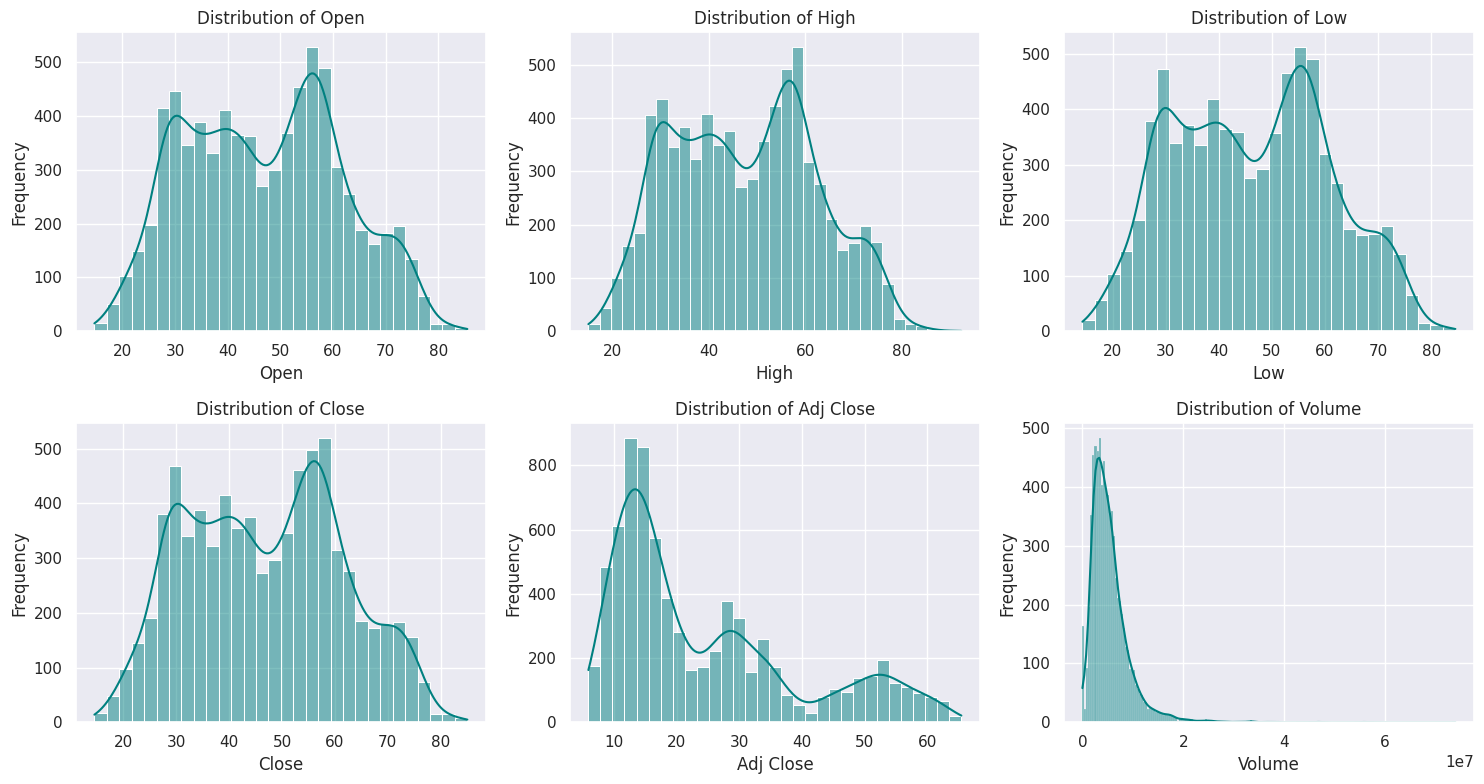

No categorical columns found (or all have high cardinality).


In [12]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

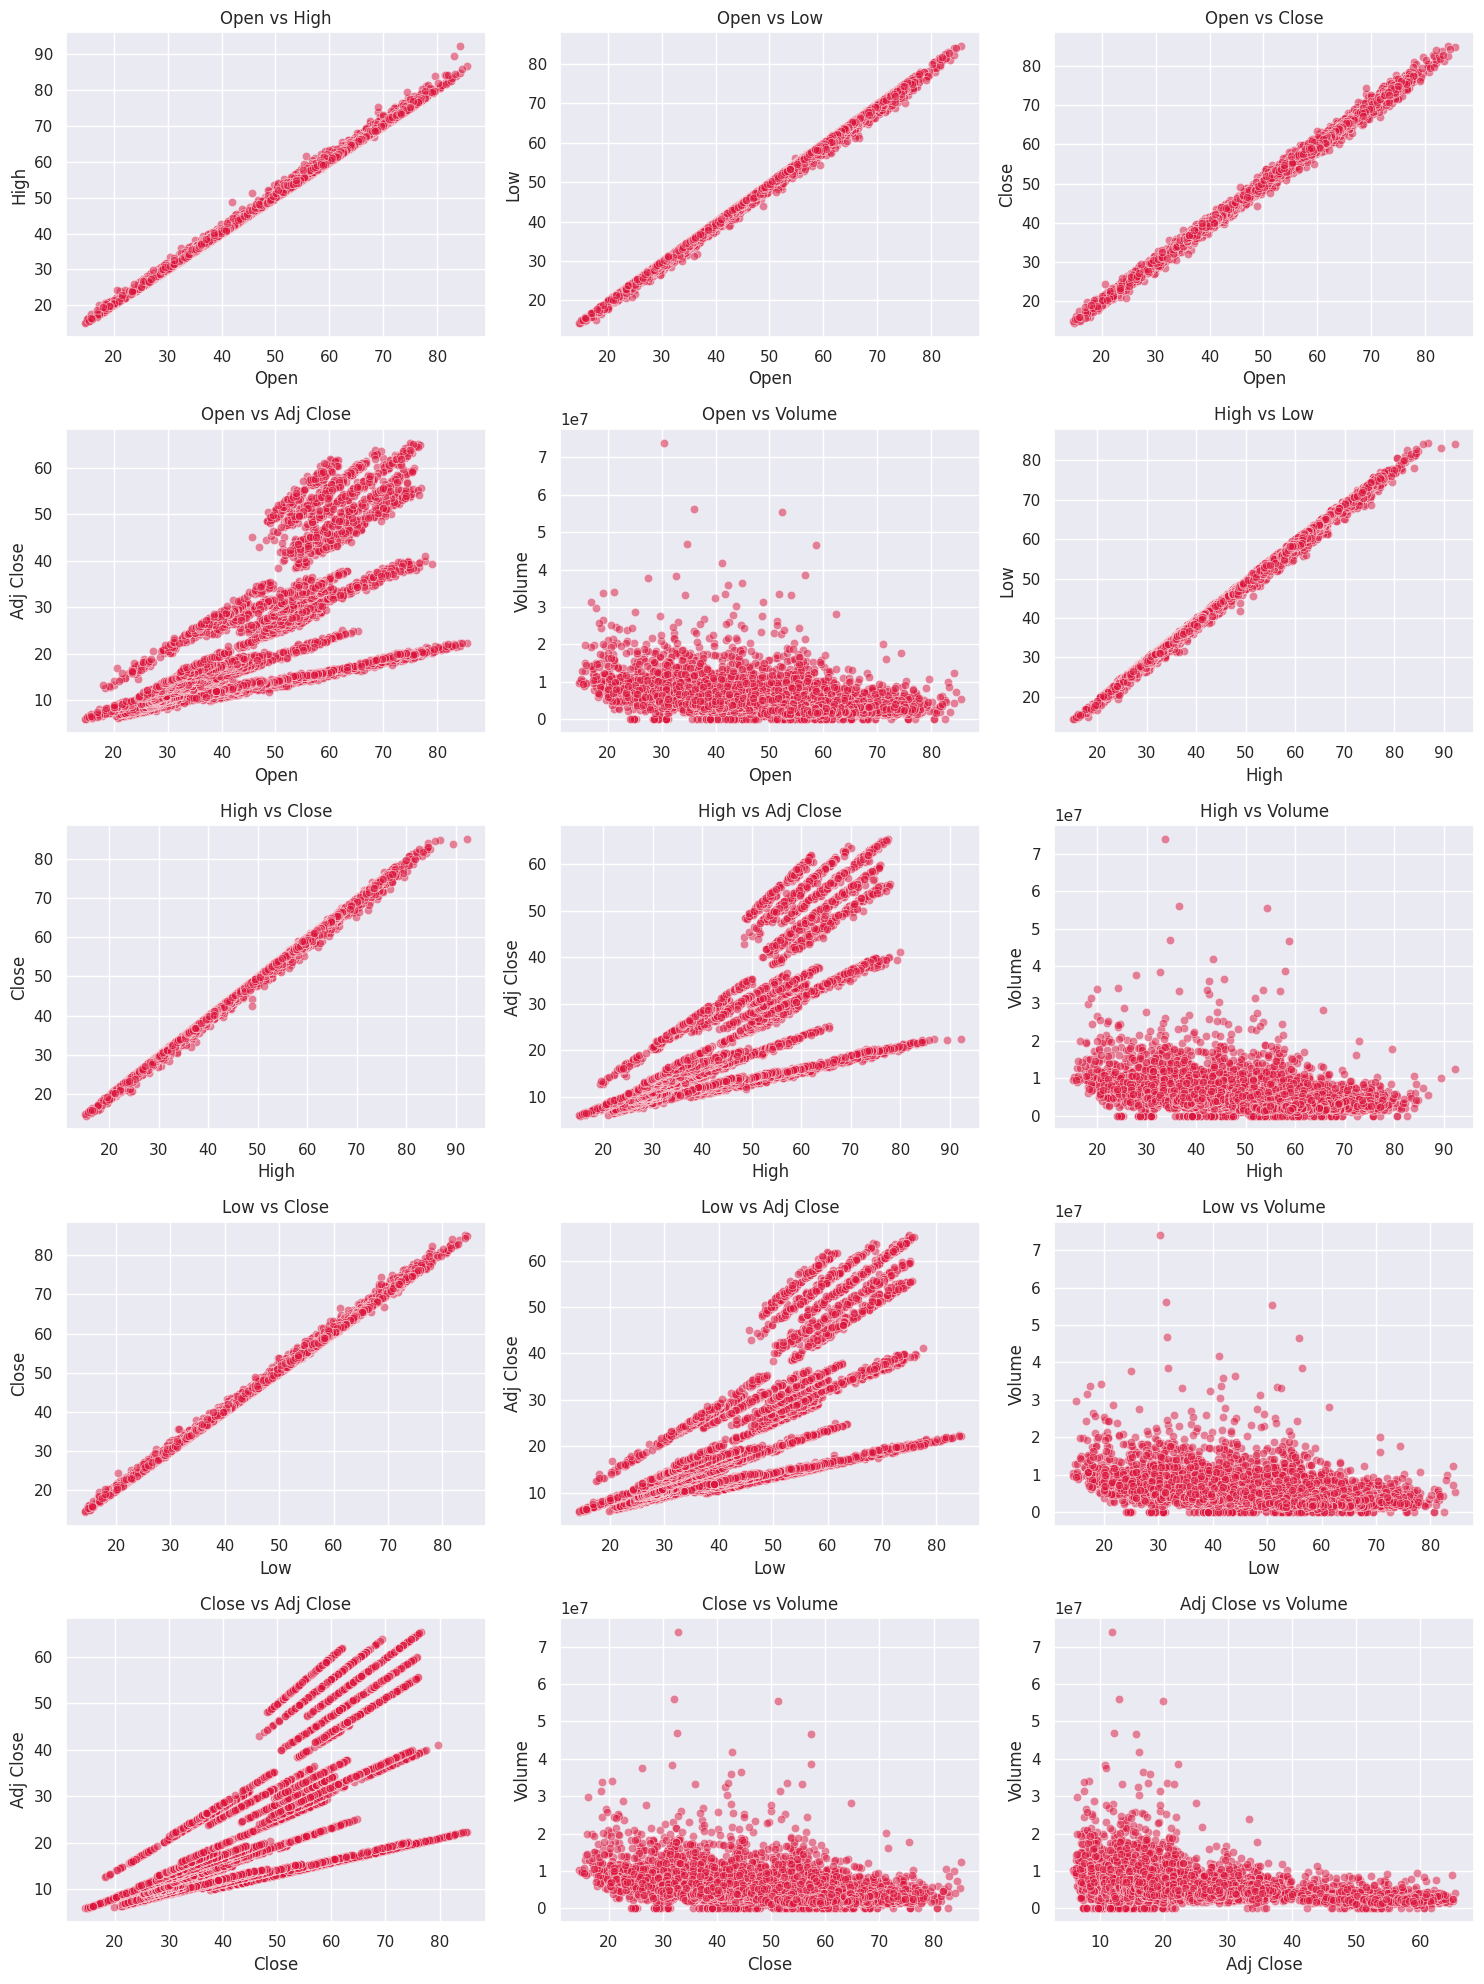

No categorical-numerical pairs found.


In [13]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

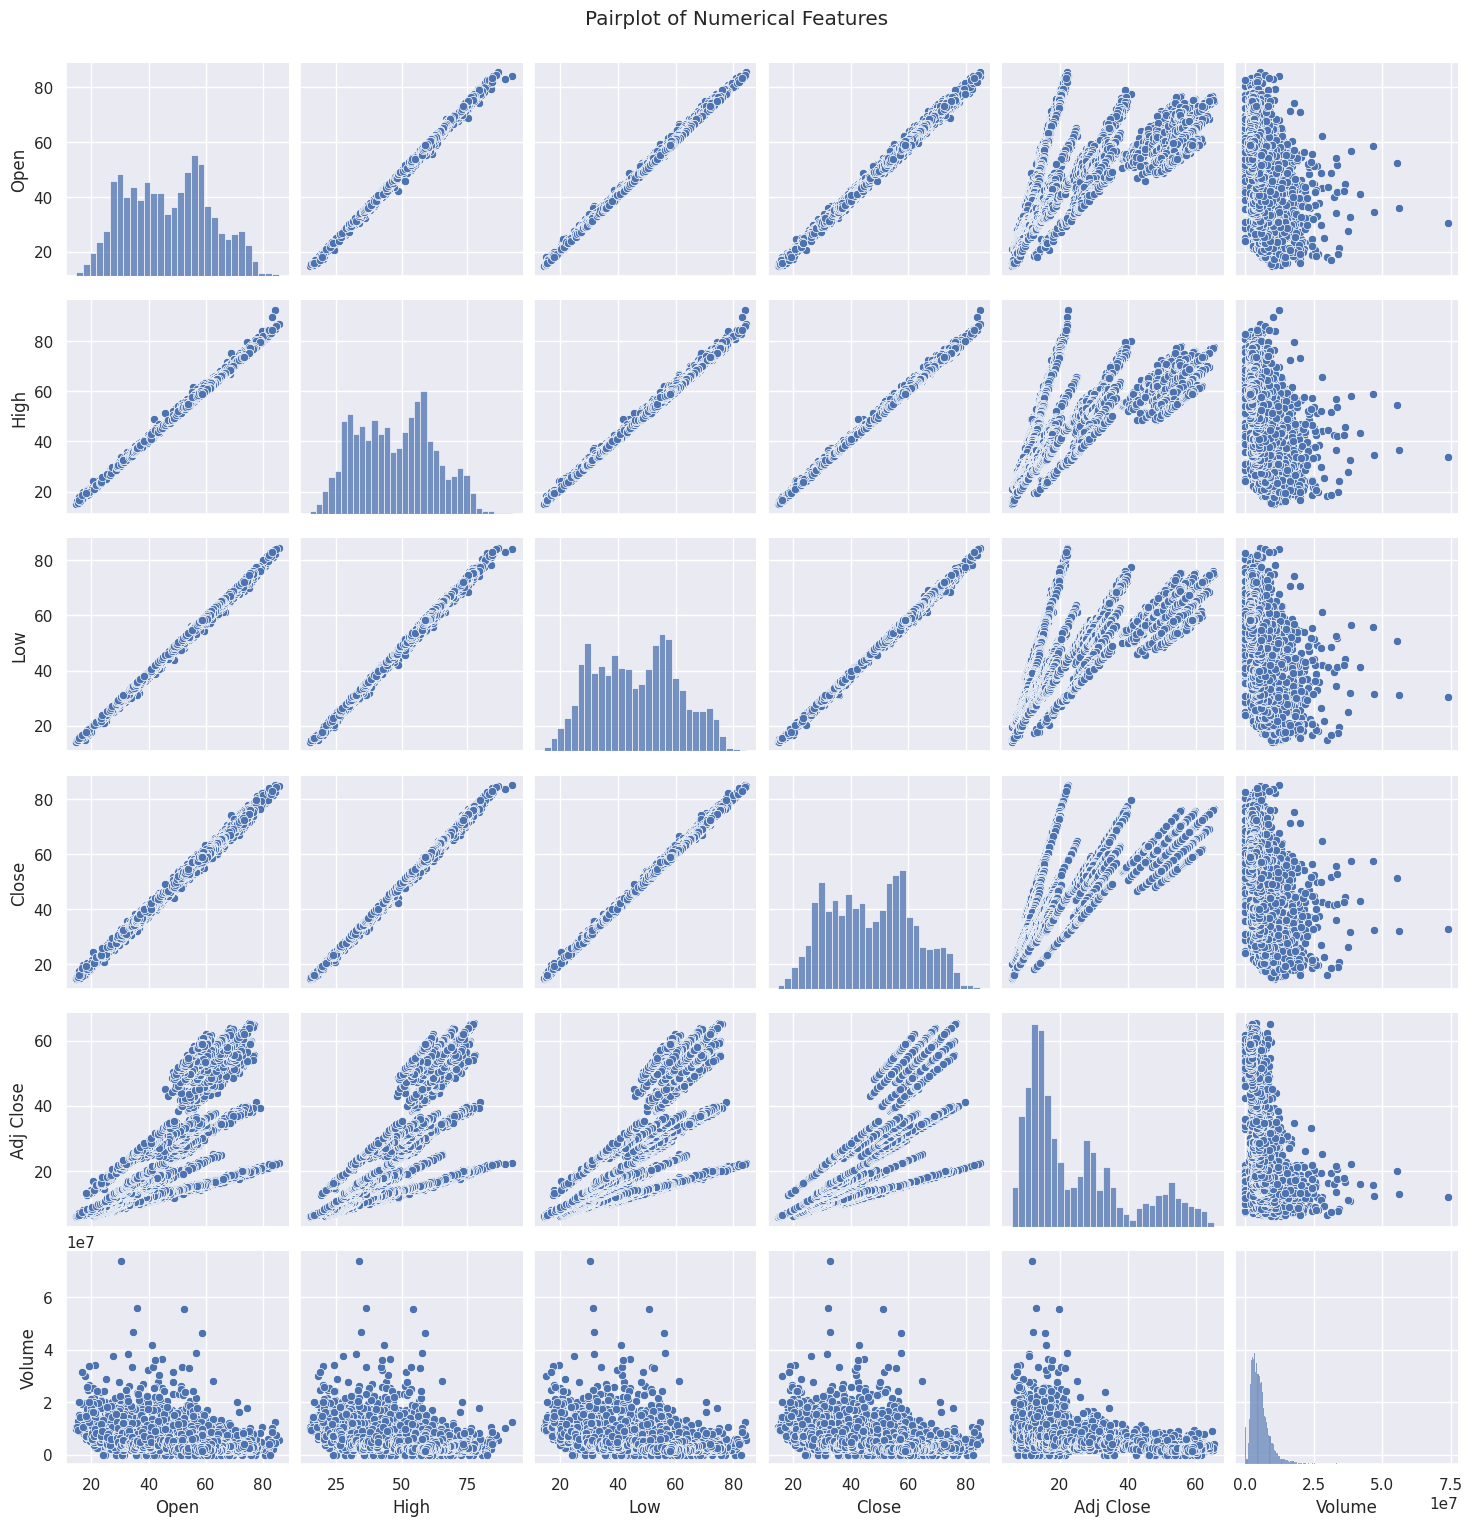

In [14]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

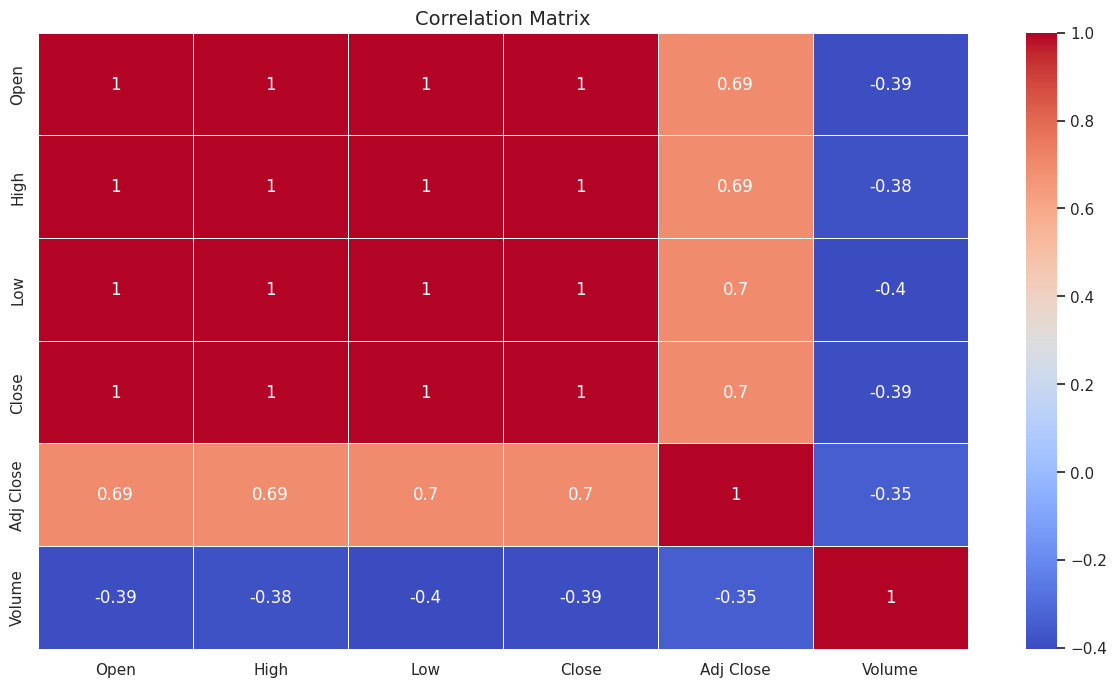

In [15]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. ENGINEERING LOG RETURNS ---
 Log Returns Calculated: Analyzed 7,510 trading days.

--- 2. THE 'BLACK SWAN' TEST (JARQUE-BERA) ---
Jarque-Bera P-Value: 0.0000e+00
 Insight: Mercedes returns mathematically REJECT the Normal Distribution.
   -> The data contains 'Fat Tails' (Leptokurtic). Extreme market crashes happen far more frequently than theoretical models predict.


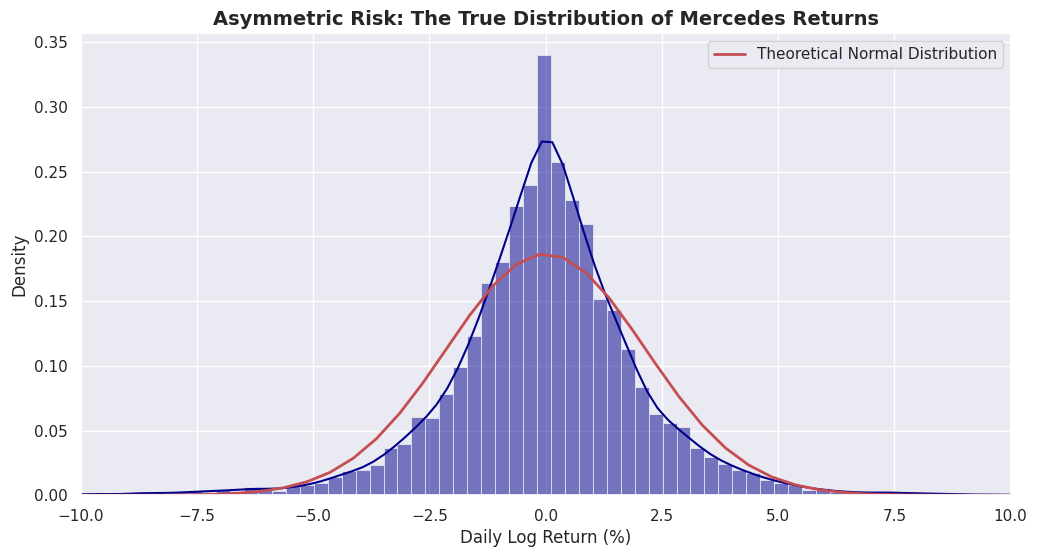


--- 3. STATIONARITY & MEAN REVERSION (ADF TEST) ---
 ADF Test Statistic: -15.1771
 P-Value: 6.2717e-28
 Insight: The Daily Returns are strictly 'Stationary'.
 -> Mathematical translation: The stock is mean-reverting. Market panics and euphoric rallies always eventually collapse back to the historical baseline variance.

--- 4. EXTREME TAIL RISK (HISTORICAL VALUE AT RISK - VaR) ---
 99% Value at Risk (VaR): -6.19%
 -> Expectation: On 99 out of 100 trading days, Mercedes will NOT drop more than 6.19%.
 99% Conditional VaR (Expected Shortfall): -8.10%
 -> Expectation: On the 1 terrible day where VaR is breached (a true market crash), the average expected drop is 8.10%.


In [16]:
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller

print("--- 1. ENGINEERING LOG RETURNS ---")
# Statistical tests cannot be run on raw stock prices because prices compound over 30 years.
# We MUST calculate the Logarithmic Daily Return to mathematically stabilize the dataset.

# Ensuring Date is datetime and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Calculating Daily Log Returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df_clean = df.dropna(subset=['Log_Return']).copy()

# Converting to percentage for readability
df_clean['Log_Return_%'] = df_clean['Log_Return'] * 100

print(f" Log Returns Calculated: Analyzed {len(df_clean):,} trading days.")


# :::::: ECONOMETRIC RISK DIAGNOSTICS ::::::

print("\n--- 2. THE 'BLACK SWAN' TEST (JARQUE-BERA) ---")
# Hypothesis: Do Mercedes-Benz daily returns follow a perfect normal distribution (Bell Curve)?
# If not, standard risk models (like standard deviation) will severely underestimate crash risks.

# We use Jarque-Bera because it is optimized for large financial time-series datasets
jb_stat, p_val_jb = stats.jarque_bera(df_clean['Log_Return_%'])

print(f"Jarque-Bera P-Value: {p_val_jb:.4e}")
if p_val_jb < 0.05:
    print(" Insight: Mercedes returns mathematically REJECT the Normal Distribution.")
    print("   -> The data contains 'Fat Tails' (Leptokurtic). Extreme market crashes happen far more frequently than theoretical models predict.")
else:
    print(" Insight: The returns perfectly follow a normal distribution.")

# Visualizing the True Distribution vs Expectation
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['Log_Return_%'], bins=150, kde=True, color='darkblue', stat="density")

# Overlaying the theoretical Normal Distribution
mu, std = df_clean['Log_Return_%'].mean(), df_clean['Log_Return_%'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Theoretical Normal Distribution')
plt.title('Asymmetric Risk: The True Distribution of Mercedes Returns', fontsize=14, fontweight='bold')
plt.xlabel('Daily Log Return (%)', fontsize=12)
plt.xlim(-10, 10)
plt.legend()
plt.show()


print("\n--- 3. STATIONARITY & MEAN REVERSION (ADF TEST) ---")
# Does this stock possess explosive, non-stationary momentum,
# or is it 'Stationary' (meaning its volatility profile does not permanently change over decades)?

adf_result = adfuller(df_clean['Log_Return_%'])

print(f" ADF Test Statistic: {adf_result[0]:.4f}")
print(f" P-Value: {adf_result[1]:.4e}")

if adf_result[1] < 0.05:
    print(" Insight: The Daily Returns are strictly 'Stationary'.")
    print(" -> Mathematical translation: The stock is mean-reverting. Market panics and euphoric rallies always eventually collapse back to the historical baseline variance.")
else:
    print(" Insight: The data is non-stationary. The mathematical rules governing this stock are permanently shifting.")


print("\n--- 4. EXTREME TAIL RISK (HISTORICAL VALUE AT RISK - VaR) ---")
# Portfolio Managers need to know the worst-case scenario.
# Here we calculate the 99% Confidence Value at Risk (VaR) and Expected Shortfall (CVaR).

# 99% VaR: The threshold where the worst 1% of trading days begin.
var_99 = np.percentile(df_clean['Log_Return_%'], 1)

# 99% CVaR (Expected Shortfall): The mathematical average return of that worst 1% of days.
cvar_99 = df_clean[df_clean['Log_Return_%'] <= var_99]['Log_Return_%'].mean()

print(f" 99% Value at Risk (VaR): {var_99:.2f}%")
print(f" -> Expectation: On 99 out of 100 trading days, Mercedes will NOT drop more than {abs(var_99):.2f}%.")

print(f" 99% Conditional VaR (Expected Shortfall): {cvar_99:.2f}%")
print(f" -> Expectation: On the 1 terrible day where VaR is breached (a true market crash), the average expected drop is {abs(cvar_99):.2f}%.")

# Time-Series Analysis

### Macro-Trend & Volatility Bounds

--- 1. MACRO-TREND MOMENTUM (50/200 SMA CROSSOVERS) ---


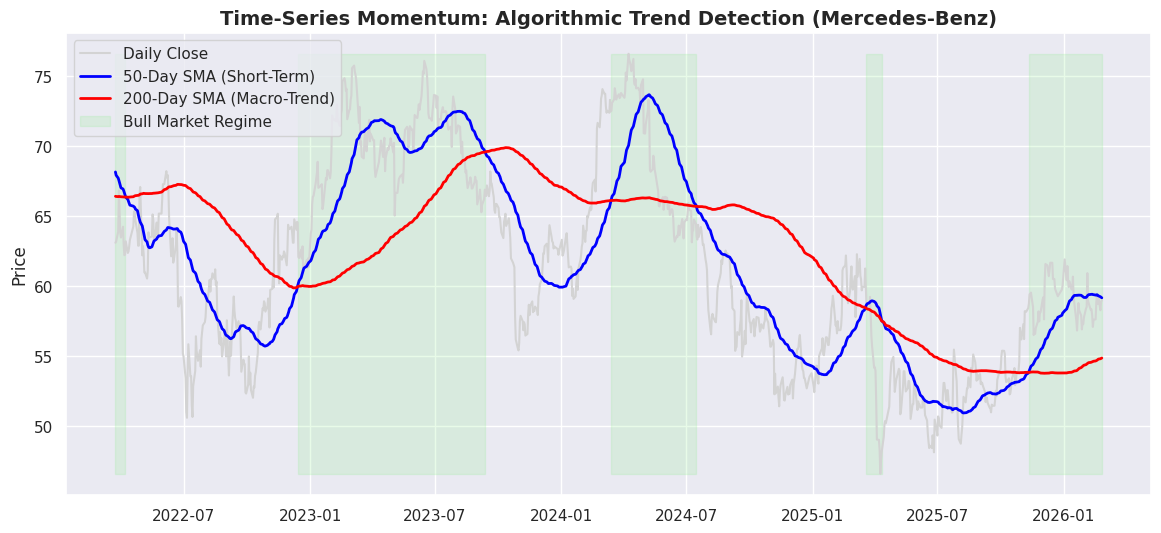


--- 2. MEAN-REVERTING VOLATILITY BOUNDS (BOLLINGER BANDS) ---


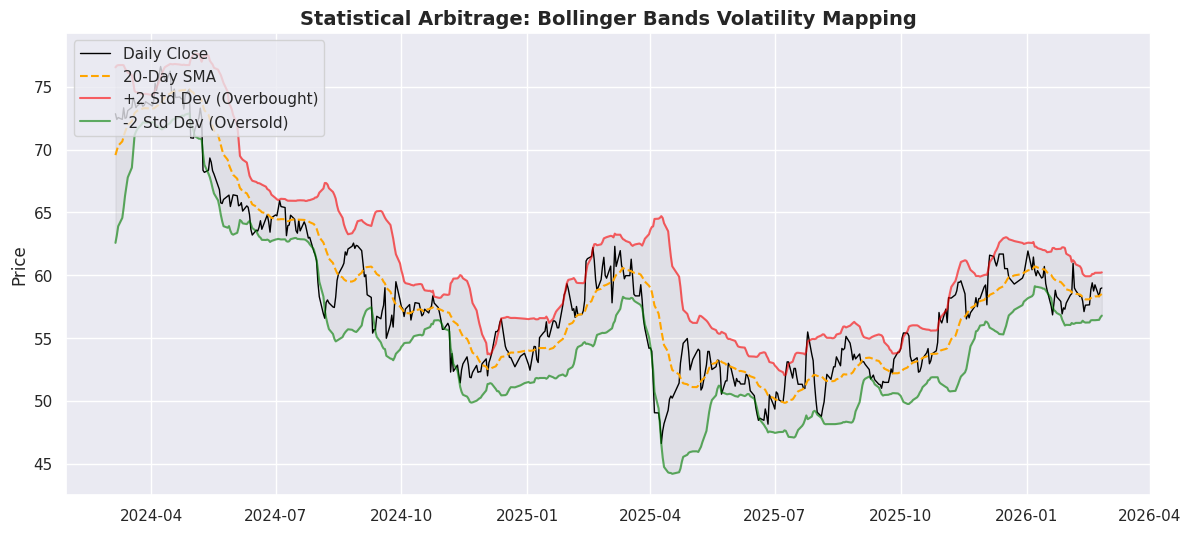


--- 3. RELATIVE STRENGTH INDEX (RSI) & MACD ---


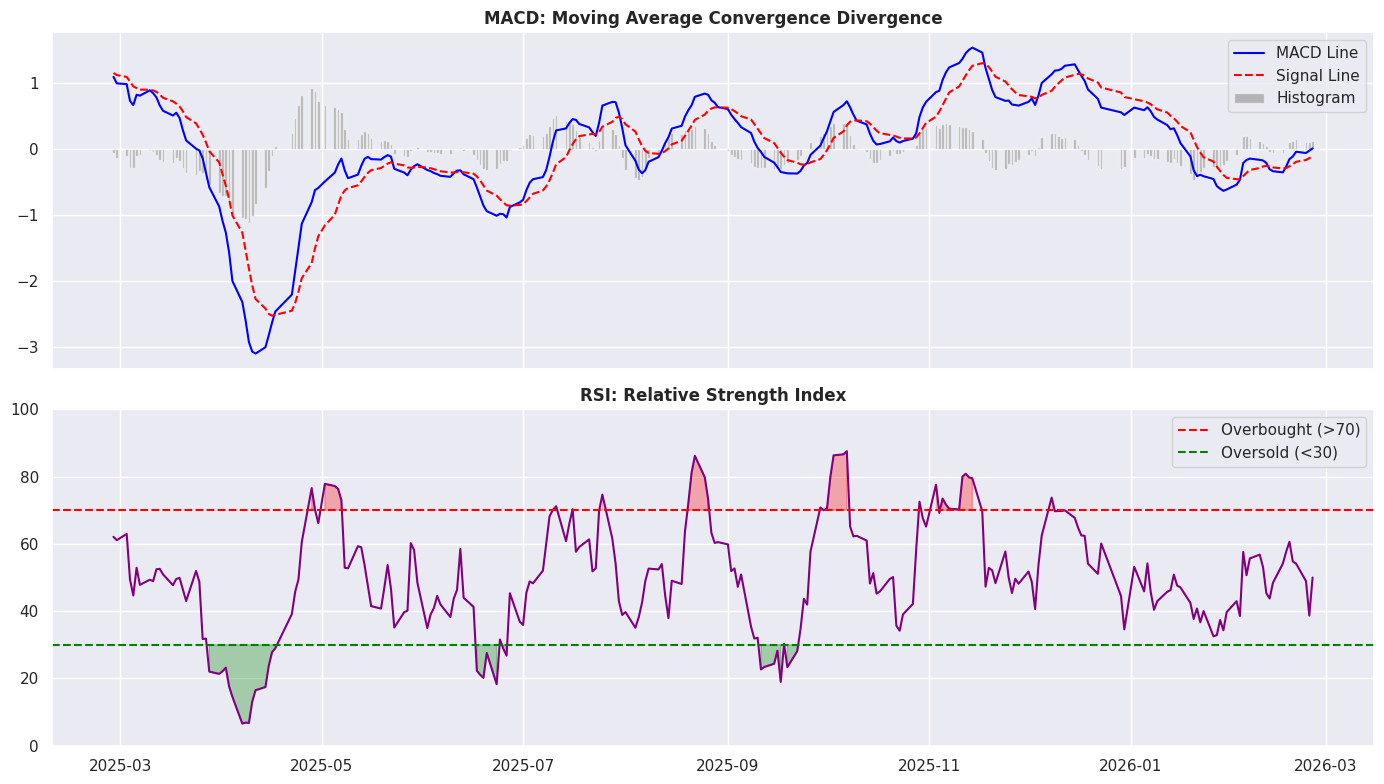

In [17]:
print("--- 1. MACRO-TREND MOMENTUM (50/200 SMA CROSSOVERS) ---")
# Hedge funds use the 50-Day and 200-Day Simple Moving Averages to detect 'Golden' and 'Death' crosses.

df_clean['SMA_50'] = df_clean['Close'].rolling(window=50).mean()
df_clean['SMA_200'] = df_clean['Close'].rolling(window=200).mean()

# Defining structural regimes
df_clean['Trend_Regime'] = np.where(df_clean['SMA_50'] > df_clean['SMA_200'], 1, -1)

recent_history = df_clean.tail(1000)

plt.figure(figsize=(14, 6))
plt.plot(recent_history['Date'], recent_history['Close'], color='lightgray', label='Daily Close')
plt.plot(recent_history['Date'], recent_history['SMA_50'], color='blue', linewidth=2, label='50-Day SMA (Short-Term)')
plt.plot(recent_history['Date'], recent_history['SMA_200'], color='red', linewidth=2, label='200-Day SMA (Macro-Trend)')

# Highlight Bullish Regimes
plt.fill_between(recent_history['Date'], recent_history['Close'].min(), recent_history['Close'].max(),
                 where=(recent_history['Trend_Regime'] == 1), color='lightgreen', alpha=0.2, label='Bull Market Regime')

plt.title('Time-Series Momentum: Algorithmic Trend Detection (Mercedes-Benz)', fontsize=14, fontweight='bold')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.show()


print("\n--- 2. MEAN-REVERTING VOLATILITY BOUNDS (BOLLINGER BANDS) ---")
# Prices revert to the mean. We map 2 Standard Deviations above and below a 20-Day SMA.
# A breach of the upper band is mathematically 'Overbought'; lower band is 'Oversold'.

df_clean['SMA_20'] = df_clean['Close'].rolling(window=20).mean()
df_clean['Rolling_Std_20'] = df_clean['Close'].rolling(window=20).std()

df_clean['Bollinger_Upper'] = df_clean['SMA_20'] + (df_clean['Rolling_Std_20'] * 2)
df_clean['Bollinger_Lower'] = df_clean['SMA_20'] - (df_clean['Rolling_Std_20'] * 2)

recent_bb = df_clean.tail(500)

plt.figure(figsize=(14, 6))
plt.plot(recent_bb['Date'], recent_bb['Close'], color='black', label='Daily Close', linewidth=1)
plt.plot(recent_bb['Date'], recent_bb['SMA_20'], color='orange', linestyle='--', label='20-Day SMA')
plt.plot(recent_bb['Date'], recent_bb['Bollinger_Upper'], color='red', alpha=0.6, label='+2 Std Dev (Overbought)')
plt.plot(recent_bb['Date'], recent_bb['Bollinger_Lower'], color='green', alpha=0.6, label='-2 Std Dev (Oversold)')
plt.fill_between(recent_bb['Date'], recent_bb['Bollinger_Lower'], recent_bb['Bollinger_Upper'], color='gray', alpha=0.1)

plt.title('Statistical Arbitrage: Bollinger Bands Volatility Mapping', fontsize=14, fontweight='bold')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.show()

# :::::: ALGORITHMIC OSCILLATORS (HFT SIGNALS) ::::::

print("\n--- 3. RELATIVE STRENGTH INDEX (RSI) & MACD ---")

# --- RSI (14-Day) ---
delta = df_clean['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_clean['RSI'] = 100 - (100 / (1 + rs))

# --- MACD (12, 26, 9) ---
ema_12 = df_clean['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df_clean['Close'].ewm(span=26, adjust=False).mean()
df_clean['MACD'] = ema_12 - ema_26
df_clean['MACD_Signal'] = df_clean['MACD'].ewm(span=9, adjust=False).mean()

# Visualize Oscillators (Last 1 Year)
recent_osc = df_clean.tail(252)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# MACD
ax1.plot(recent_osc['Date'], recent_osc['MACD'], color='blue', label='MACD Line')
ax1.plot(recent_osc['Date'], recent_osc['MACD_Signal'], color='red', linestyle='--', label='Signal Line')
ax1.bar(recent_osc['Date'], recent_osc['MACD'] - recent_osc['MACD_Signal'], color='gray', alpha=0.5, label='Histogram')
ax1.set_title('MACD: Moving Average Convergence Divergence', fontweight='bold')
ax1.legend()

# RSI
ax2.plot(recent_osc['Date'], recent_osc['RSI'], color='purple')
ax2.axhline(70, color='red', linestyle='--', label='Overbought (>70)')
ax2.axhline(30, color='green', linestyle='--', label='Oversold (<30)')
ax2.fill_between(recent_osc['Date'], recent_osc['RSI'], 70, where=(recent_osc['RSI'] >= 70), color='red', alpha=0.3)
ax2.fill_between(recent_osc['Date'], recent_osc['RSI'], 30, where=(recent_osc['RSI'] <= 30), color='green', alpha=0.3)
ax2.set_title('RSI: Relative Strength Index', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()

### Advanced Autoregressive Memory & Volatility Clustering

In [18]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 52.0 MB/s eta 0:00:00



--- 4. MARKET MEMORY DIAGNOSTICS (ACF & PACF) ---


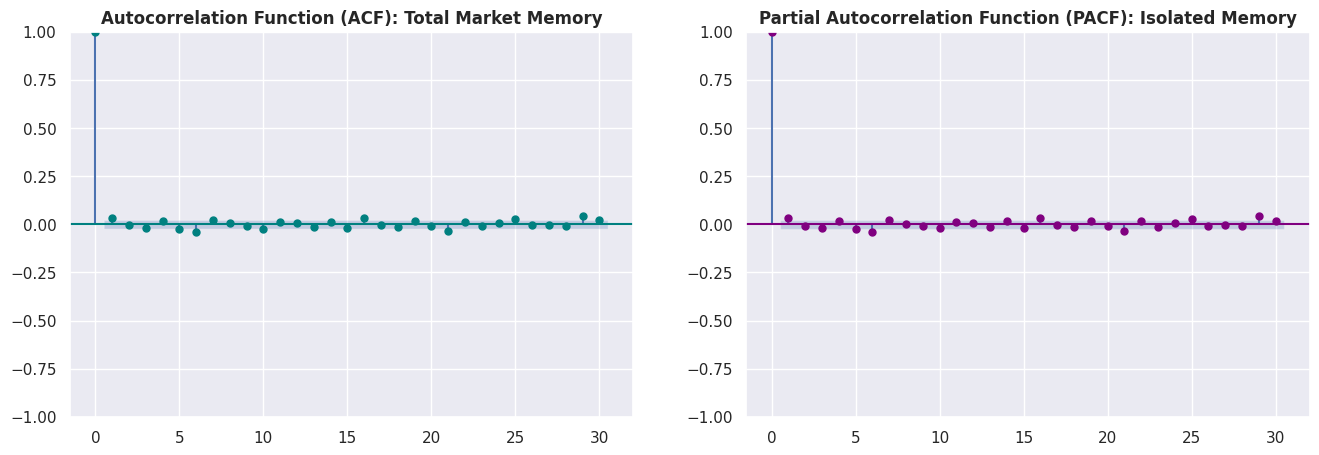


--- 5. VOLATILITY CLUSTERING (GARCH 1,1 MODEL) ---

 GARCH(1,1) Mathematical Parameters:
mu          0.035514
omega       0.050227
alpha[1]    0.063392
beta[1]     0.925405
Name: params, dtype: float64


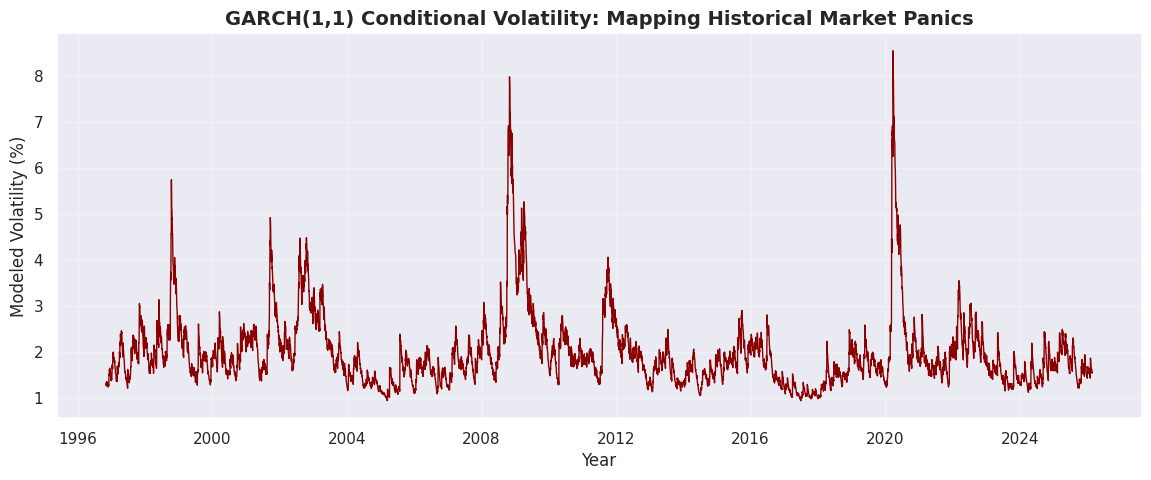

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

print("\n--- 4. MARKET MEMORY DIAGNOSTICS (ACF & PACF) ---")
# Asking A Quesions Here : Does a stock's return yesterday mathematically influence its return today?
# We will map the Autocorrelation and Partial Autocorrelation of the Log Returns.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_clean['Log_Return_%'].dropna(), lags=30, ax=ax1, color='teal', alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF): Total Market Memory', fontweight='bold')

plot_pacf(df_clean['Log_Return_%'].dropna(), lags=30, ax=ax2, color='purple', alpha=0.05)
ax2.set_title('Partial Autocorrelation Function (PACF): Isolated Memory', fontweight='bold')
plt.show()

print("\n--- 5. VOLATILITY CLUSTERING (GARCH 1,1 MODEL) ---")
# Markets experience "Volatility Clustering" (crashes cause more crashes, calm periods breed calm).
# We deploy a Generalized Autoregressive Conditional Heteroskedasticity (GARCH) model to capture this.

# Fitting the GARCH(1,1) model to the continuous log returns
garch = arch_model(df_clean['Log_Return_%'].dropna(), vol='Garch', p=1, q=1, rescale=False)
garch_fitted = garch.fit(disp='off')

print("\n GARCH(1,1) Mathematical Parameters:")
print(garch_fitted.params)

# Extracting and plotting the Conditional Volatility
df_clean['Conditional_Volatility'] = np.nan
df_clean.loc[df_clean['Log_Return_%'].dropna().index, 'Conditional_Volatility'] = garch_fitted.conditional_volatility

plt.figure(figsize=(14, 5))
plt.plot(df_clean['Date'], df_clean['Conditional_Volatility'], color='darkred', linewidth=1)
plt.title('GARCH(1,1) Conditional Volatility: Mapping Historical Market Panics', fontsize=14, fontweight='bold')
plt.ylabel('Modeled Volatility (%)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

# Feature Engineering

--- 1. AUTOREGRESSIVE LAGGED FEATURES ---
 Engineered: Autoregressive Lags (t-1 to t-3).

--- 2. SHIFTING MOMENTUM & RISK FEATURES (PREVENTING DATA LEAKAGE) ---
 Engineered: Shifted Momentum Oscillators and Volatility to prevent Data Leakage.

--- 3. DEFINING THE ALGORITHMIC TARGET VARIABLE (Y) ---
 Engineered: Binary Target Variable (Next Day Direction).

--- 4. DATA SANITIZATION & MATRIX SCALING ---
 Data Sanitized: 7,310 viable trading days remaining.
 Feature Matrix (X) successfully standardized (Mean=0, Variance=1).

 Final Scaled Feature Matrix (X) Preview:
      Return_Lag_1  Return_Lag_2  Return_Lag_3  RSI_Lag_1  MACD_Lag_1  \
7505      0.425120      0.966319      0.024597   0.534194   -0.138413   
7506     -0.511217      0.425095      0.966305   0.207385   -0.100921   
7507      0.386680     -0.511231      0.425069   0.171643   -0.033111   
7508     -0.743345      0.386656     -0.511277  -0.119757   -0.051020   
7509      0.500253     -0.743357      0.386629  -0.691342   -0.01

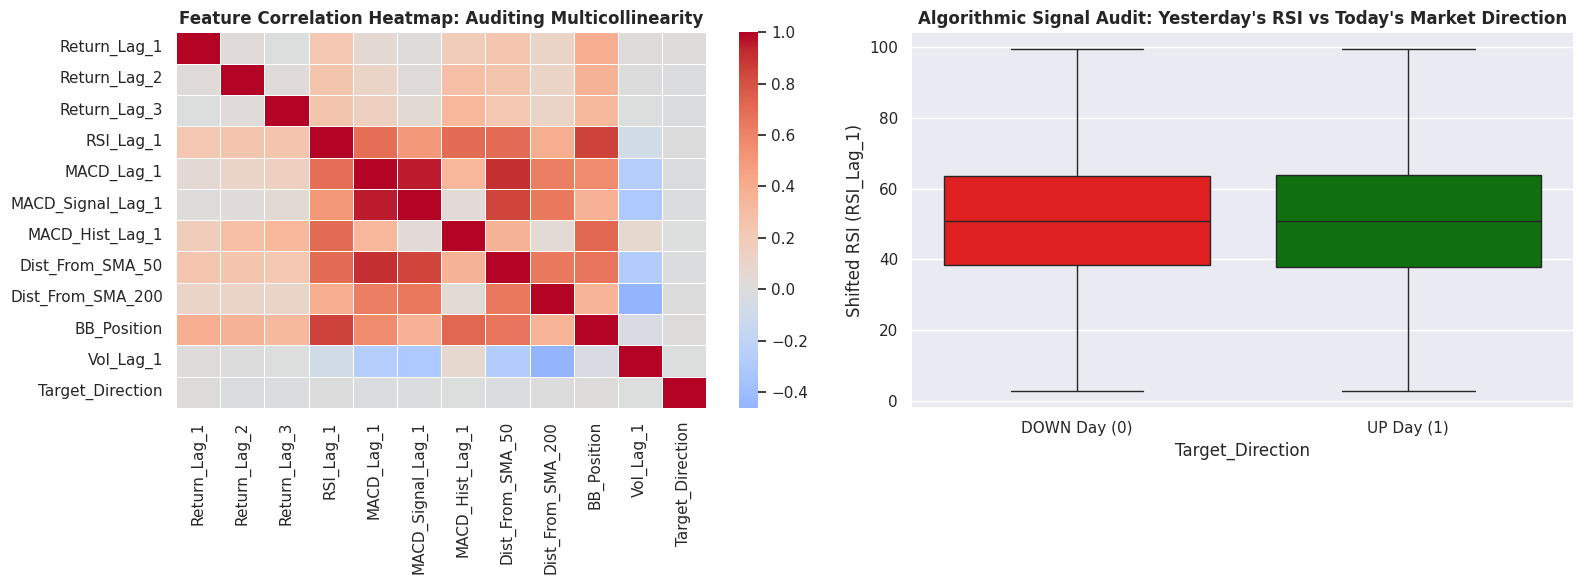

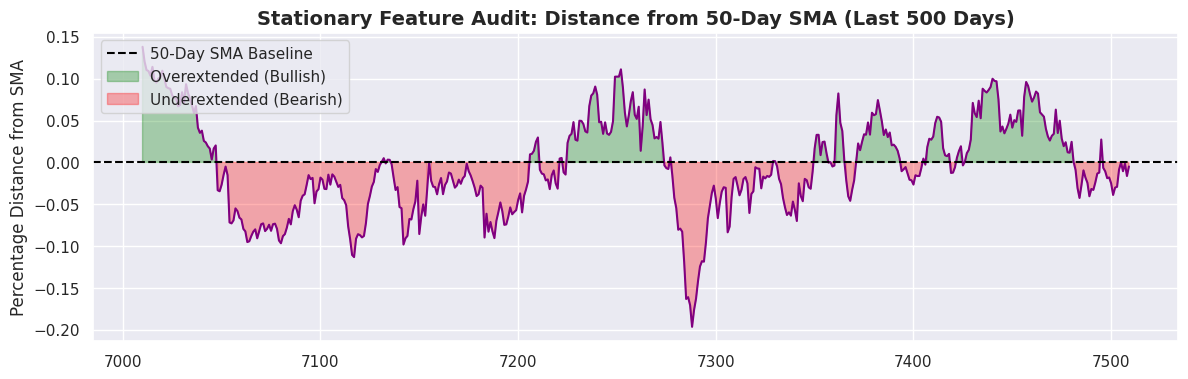

In [20]:
from sklearn.preprocessing import StandardScaler

print("--- 1. AUTOREGRESSIVE LAGGED FEATURES ---")
# To predict tomorrow's stock movement, the algorithm needs to know what happened today,
# yesterday, and the day before. We create "Lagged" features (shifting the data backward).

# Ensuring data is sorted chronologically
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

# Engineering Lagged Returns (t-1, t-2, t-3)
df_clean['Return_Lag_1'] = df_clean['Log_Return_%'].shift(1)
df_clean['Return_Lag_2'] = df_clean['Log_Return_%'].shift(2)
df_clean['Return_Lag_3'] = df_clean['Log_Return_%'].shift(3)

print(" Engineered: Autoregressive Lags (t-1 to t-3).")


print("\n--- 2. SHIFTING MOMENTUM & RISK FEATURES (PREVENTING DATA LEAKAGE) ---")
# We are calculated MACD, RSI, and Bollinger Bands in Phase 3/4.
# We must shift them by 1 day. If we use today's closing RSI to predict today's close,
# the algorithm is cheating (Look-Ahead Bias).

df_clean['RSI_Lag_1'] = df_clean['RSI'].shift(1)
df_clean['MACD_Lag_1'] = df_clean['MACD'].shift(1)
df_clean['MACD_Signal_Lag_1'] = df_clean['MACD_Signal'].shift(1)
df_clean['MACD_Hist_Lag_1'] = (df_clean['MACD'] - df_clean['MACD_Signal']).shift(1)

# Distance from Moving Averages (Is the stock overextended relative to its trend?)
df_clean['Dist_From_SMA_50'] = ((df_clean['Close'] - df_clean['SMA_50']) / df_clean['SMA_50']).shift(1)
df_clean['Dist_From_SMA_200'] = ((df_clean['Close'] - df_clean['SMA_200']) / df_clean['SMA_200']).shift(1)

# Bollinger Band Positioning (1 = at upper band, 0 = at lower band)
df_clean['BB_Position'] = ((df_clean['Close'] - df_clean['Bollinger_Lower']) /
                           (df_clean['Bollinger_Upper'] - df_clean['Bollinger_Lower'])).shift(1)

# Shifting the GARCH Volatility from Phase 5
if 'Conditional_Volatility' in df_clean.columns:
    df_clean['Vol_Lag_1'] = df_clean['Conditional_Volatility'].shift(1)

print(" Engineered: Shifted Momentum Oscillators and Volatility to prevent Data Leakage.")


print("\n--- 3. DEFINING THE ALGORITHMIC TARGET VARIABLE (Y) ---")
# Financial markets are too noisy for an algorithm to predict the EXACT future price.
# Instead, Quantitative Funds frame this as a Binary Classification problem:
# Will the stock go UP (1) or DOWN (0) tomorrow?

# The Target is tomorrow's actual return direction (which is just today's unshifted return)
# Wait, let's be precise: We want to predict df_clean['Log_Return_%'] based on the LAGS.
# So if Log_Return_% > 0, the target is 1 (UP).
df_clean['Target_Direction'] = np.where(df_clean['Log_Return_%'] > 0, 1, 0)

print(" Engineered: Binary Target Variable (Next Day Direction).")


print("\n--- 4. DATA SANITIZATION & MATRIX SCALING ---")
# We must standardize the features so the algorithm doesn't overweight large numbers
# (like MACD) over small numbers (like Log Returns).

# Defining the final feature matrix
ml_features = [
    'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3',
    'RSI_Lag_1', 'MACD_Lag_1', 'MACD_Signal_Lag_1', 'MACD_Hist_Lag_1',
    'Dist_From_SMA_50', 'Dist_From_SMA_200', 'BB_Position'
]

if 'Vol_Lag_1' in df_clean.columns:
    ml_features.append('Vol_Lag_1')

# Dropping all NaN rows created by our rolling windows and lagged shifts
ml_df = df_clean.dropna(subset=ml_features + ['Target_Direction', 'Log_Return_%']).copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Scaling the feature matrix (X)
X_unscaled = ml_df[ml_features]
X_scaled = pd.DataFrame(scaler.fit_transform(X_unscaled), columns=ml_features, index=ml_df.index)

# Defining the Target (y)
y = ml_df['Target_Direction']

print(f" Data Sanitized: {len(ml_df):,} viable trading days remaining.")
print(f" Feature Matrix (X) successfully standardized (Mean=0, Variance=1).")

# Previewing the final, machine-readable dataset
print("\n Final Scaled Feature Matrix (X) Preview:")
print(X_scaled.tail())

print("--- VISUALIZING THE QUANTITATIVE FEATURE SPACE ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feature Correlation Heatmap (Detecting Multicollinearity)
# We want features to correlate with the Target, but NOT perfectly with each other.
# We use the unscaled dataframe for interpretability here.
correlation_matrix = ml_df[ml_features + ['Target_Direction']].corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap: Auditing Multicollinearity', fontsize=12, fontweight='bold')

# 2. Target Distribution Breakdown (RSI vs Next Day Direction)

# Does a high/low RSI yesterday actually translate to a different return today?
# Target_Direction: 0 = DOWN Day, 1 = UP Day
sns.boxplot(x='Target_Direction', y='RSI_Lag_1', data=ml_df, palette=['red', 'green'], ax=axes[1])
axes[1].set_title('Algorithmic Signal Audit: Yesterday\'s RSI vs Today\'s Market Direction', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['DOWN Day (0)', 'UP Day (1)'])
axes[1].set_ylabel('Shifted RSI (RSI_Lag_1)')
plt.tight_layout()
plt.show()

# 3. Visualizing Stationary Momentum (Distance from 50-Day SMA)
# This proves we successfully transformed a trending price into a stationary, mean-reverting oscillator.
plt.figure(figsize=(14, 4))
plt.plot(ml_df.index[-500:], ml_df['Dist_From_SMA_50'].tail(500), color='purple', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', label='50-Day SMA Baseline')
plt.fill_between(ml_df.index[-500:], ml_df['Dist_From_SMA_50'].tail(500), 0,
                 where=(ml_df['Dist_From_SMA_50'].tail(500) > 0), color='green', alpha=0.3, label='Overextended (Bullish)')
plt.fill_between(ml_df.index[-500:], ml_df['Dist_From_SMA_50'].tail(500), 0,
                 where=(ml_df['Dist_From_SMA_50'].tail(500) < 0), color='red', alpha=0.3, label='Underextended (Bearish)')
plt.title('Stationary Feature Audit: Distance from 50-Day SMA (Last 500 Days)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage Distance from SMA')
plt.legend(loc='upper left')
plt.show()

# Machine Learning

--- 1. CHRONOLOGICAL TRAIN/TEST SPLIT ---
 Training Set: 6302 days
 Testing Set: 1008 days (Strictly Out-of-Sample)

--- 2. TRAINING THE CLASSIFIERS ---
 Both Tree-Based Classification Architectures successfully trained.

--- 3. ALGORITHMIC EVALUATION (OUT-OF-SAMPLE) ---
 Random Forest Out-of-Sample Accuracy: 50.60%
 Random Forest Out-of-Sample Precision: 50.21%
 XGBoost Out-of-Sample Accuracy: 51.59%
 XGBoost Out-of-Sample Precision: 51.63%

 The XGBoost algorithm mathematically outperformed the alternative in trade precision.


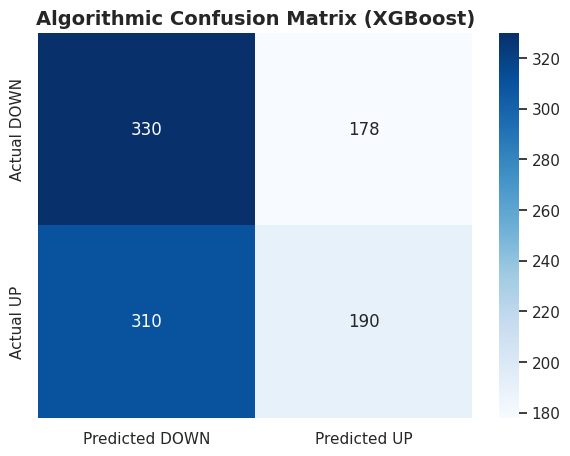


--- 4. ALGORITHMIC STRATEGY BACKTEST (EQUITY CURVE) ---


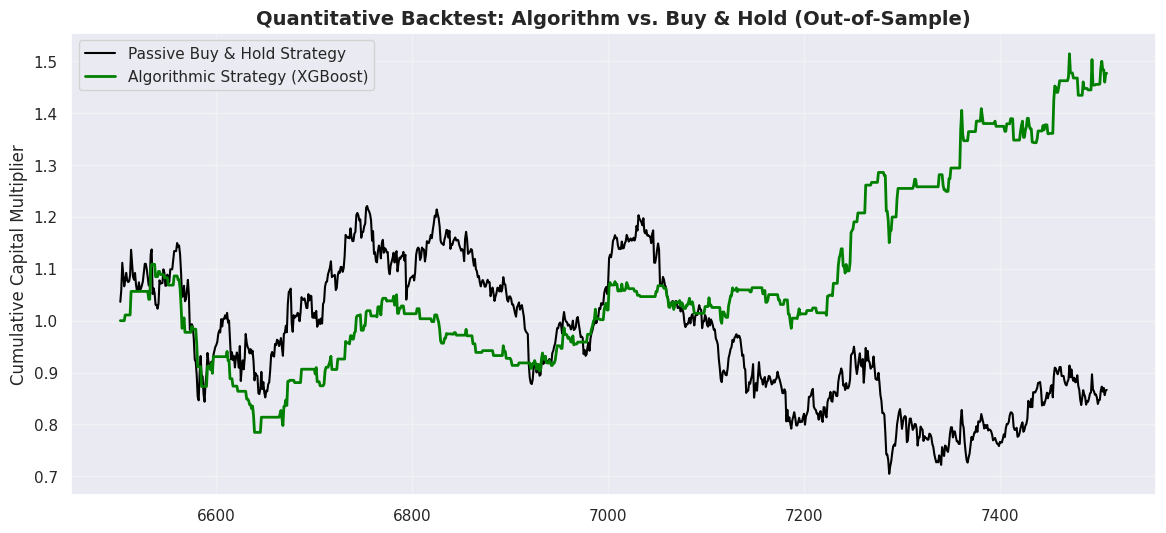

 Passive Buy & Hold Return (Last 4 Years): -13.35%
 Algorithmic Strategy Return (Last 4 Years): 47.71%

--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


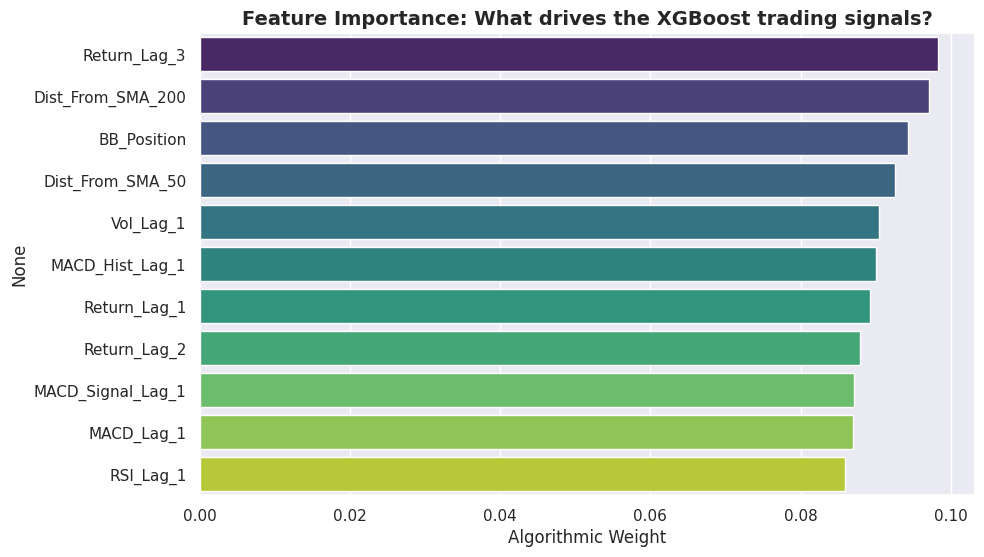

In [21]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix

print("--- 1. CHRONOLOGICAL TRAIN/TEST SPLIT ---")
# Financial data must be split chronologically to prevent look-ahead bias.
# We will train on the historical data and test the algorithm on the last 4 years of trading.

# # Approx 4 years of trading days
test_trading_days = 252 * 4
split_index = len(X_scaled) - test_trading_days

X_train = X_scaled.iloc[:split_index]
X_test = X_scaled.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f" Training Set: {len(X_train)} days")
print(f" Testing Set: {len(X_test)} days (Strictly Out-of-Sample)")


print("\n--- 2. TRAINING THE CLASSIFIERS ---")

# 1. :::::: Random Forest Classifier ::::::

# We restrict max_depth to prevent the model from memorizing historical noise
rf_classifier = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

# 2. XGBoost Classifier
xgb_classifier = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
xgb_classifier.fit(X_train, y_train)

print(" Both Tree-Based Classification Architectures successfully trained.")

print("\n--- 3. ALGORITHMIC EVALUATION (OUT-OF-SAMPLE) ---")

# Forceing both models to predict the unseen Testing Set
rf_preds = rf_classifier.predict(X_test)
xgb_preds = xgb_classifier.predict(X_test)

# In trading, Precision is crucial: When the algorithm predicts an UP day, how often is it actually right?
def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    print(f" {name} Out-of-Sample Accuracy: {acc * 100:.2f}%")
    print(f" {name} Out-of-Sample Precision: {prec * 100:.2f}%")
    return prec

prec_rf = evaluate_classifier("Random Forest", y_test, rf_preds)
prec_xgb = evaluate_classifier("XGBoost", y_test, xgb_preds)

# Determining the superior architecture based on Precision
best_model_name = "XGBoost" if prec_xgb > prec_rf else "Random Forest"
best_preds = xgb_preds if prec_xgb > prec_rf else rf_preds
best_model = xgb_classifier if prec_xgb > prec_rf else rf_classifier

print(f"\n The {best_model_name} algorithm mathematically outperformed the alternative in trade precision.")

# Visualizing the Confusion Matrix of the Best Model
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted DOWN', 'Predicted UP'], yticklabels=['Actual DOWN', 'Actual UP'])
plt.title(f'Algorithmic Confusion Matrix ({best_model_name})', fontsize=14, fontweight='bold')
plt.show()


print("\n--- 4. ALGORITHMIC STRATEGY BACKTEST (EQUITY CURVE) ---")
# Here we will try to understand does this model actually make money? We will simulate a quantitative trading strategy.

# Extracting the actual daily decimal returns for the test period from the original dataframe
test_returns = df_clean.loc[X_test.index, 'Log_Return_%'] / 100

# Calculating the Buy & Hold Strategy (Passive Investing)
cumulative_buy_and_hold = (1 + test_returns).cumprod()

# Calculating the Algorithmic Strategy
# Multiplying the prediction (1 or 0) by the actual return
algo_returns = best_preds * test_returns
cumulative_algo_strategy = (1 + algo_returns).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cumulative_buy_and_hold.index, cumulative_buy_and_hold, color='black', label='Passive Buy & Hold Strategy')
plt.plot(cumulative_algo_strategy.index, cumulative_algo_strategy, color='green', linewidth=2, label=f'Algorithmic Strategy ({best_model_name})')
plt.title('Quantitative Backtest: Algorithm vs. Buy & Hold (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Capital Multiplier', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Finaling performance numbers
final_bh = (cumulative_buy_and_hold.iloc[-1] - 1) * 100
final_algo = (cumulative_algo_strategy.iloc[-1] - 1) * 100

print(f" Passive Buy & Hold Return (Last 4 Years): {final_bh:.2f}%")
print(f" Algorithmic Strategy Return (Last 4 Years): {final_algo:.2f}%")

print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")
importances = pd.Series(best_model.feature_importances_, index=ml_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title(f'Feature Importance: What drives the {best_model_name} trading signals?', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Weight', fontsize=12)
plt.show()

### Advanced Training & Hyperparamater Tuning

In [22]:
# ==========================================
# PHASE 7.5: ADVANCED TRAINING & HYPERPARAMETER TUNING
# ==========================================
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBClassifier
import joblib

print("--- 1. WALK-FORWARD CROSS-VALIDATION SETUP ---")
# Standard K-Fold Cross Validation randomly shuffles data. This causes Data Leakage in time-series.
# TimeSeriesSplit ensures the model only ever trains on the PAST to predict the FUTURE.

tscv = TimeSeriesSplit(n_splits=5)
print(" Time-Series Split configured for Walk-Forward Validation (5 Folds).")


print("\n--- 2. HYPERPARAMETER GRID SEARCH (XGBOOST) ---")
# We will test multiple mathematical configurations of the XGBoost algorithm to find the absolute best one.
# Warning: Grid searches can take a few minutes to run!

# Define the hyperparameter grid
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0] # What percentage of data trees can see (prevents overfitting)
}

# Initialize the base model
base_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Initialize the Grid Search using our Time-Series Cross Validator
grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='precision',
    n_jobs=-1,
    verbose=1
)

print(" Executing Grid Search Optimization across chronological folds...")
grid_search.fit(X_train, y_train)

# Extracting the absolute best mathematical model
optimized_xgb = grid_search.best_estimator_

print("\n OPTIMIZATION COMPLETE! Best Algorithmic Parameters:")
for key, value in grid_search.best_params_.items():
    print(f"   -> {key}: {value}")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION (OPTIMIZED MODEL) ---")
# Let's test the newly optimized algorithm on the unseen 4-year test set.

optimized_preds = optimized_xgb.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score

opt_acc = accuracy_score(y_test, optimized_preds)
opt_prec = precision_score(y_test, optimized_preds)

print(f" Optimized Accuracy: {opt_acc * 100:.2f}%")
print(f" Optimized Precision: {opt_prec * 100:.2f}%")


print("\n--- 4. MODEL SERIALIZATION (SAVING THE ALGORITHM) ---")
# Once a quantitative algorithm is trained, it must be exported so it can be deployed
# to a live trading server or API. We serialize it using joblib.

model_filename = "Mercedes_Benz_XGBoost_Trading_Algo.pkl"
joblib.dump(optimized_xgb, model_filename)

print(f" SUCCESS: The optimized quantitative algorithm has been saved as '{model_filename}'")
print("   -> It is now ready for live market deployment!")

--- 1. WALK-FORWARD CROSS-VALIDATION SETUP ---
 Time-Series Split configured for Walk-Forward Validation (5 Folds).

--- 2. HYPERPARAMETER GRID SEARCH (XGBOOST) ---
 Executing Grid Search Optimization across chronological folds...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

 OPTIMIZATION COMPLETE! Best Algorithmic Parameters:
   -> learning_rate: 0.1
   -> max_depth: 5
   -> n_estimators: 200
   -> subsample: 0.8

--- 3. OUT-OF-SAMPLE EVALUATION (OPTIMIZED MODEL) ---
 Optimized Accuracy: 51.09%
 Optimized Precision: 50.83%

--- 4. MODEL SERIALIZATION (SAVING THE ALGORITHM) ---
 SUCCESS: The optimized quantitative algorithm has been saved as 'Mercedes_Benz_XGBoost_Trading_Algo.pkl'
   -> It is now ready for live market deployment!


# Deep Quantitative Learning ( LSTM )

--- 1. TENSOR RESHAPING (3D MATRIX EXPANSION) ---
 Training Tensor successfully reshaped to 3D: (6302, 1, 11)

--- 2. LSTM NETWORK ARCHITECTURE ---
 LSTM Network Architecture successfully compiled.

--- 3. DEEP LEARNING EXECUTION (EPOCH TRAINING) ---
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4903 - loss: 0.6953 - val_accuracy: 0.5099 - val_loss: 0.6926
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5065 - loss: 0.6934 - val_accuracy: 0.4901 - val_loss: 0.6934
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5106 - loss: 0.6928 - val_accuracy: 0.4940 - val_loss: 0.6935
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5317 - loss: 0.6910 - val_accuracy: 0.5099 - val_loss: 0.6928
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5279 - loss: 0.6919 - val_accuracy: 0.4950 - val_loss: 0.6936
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5210 - loss: 0.6919 - val_accuracy: 0.5020

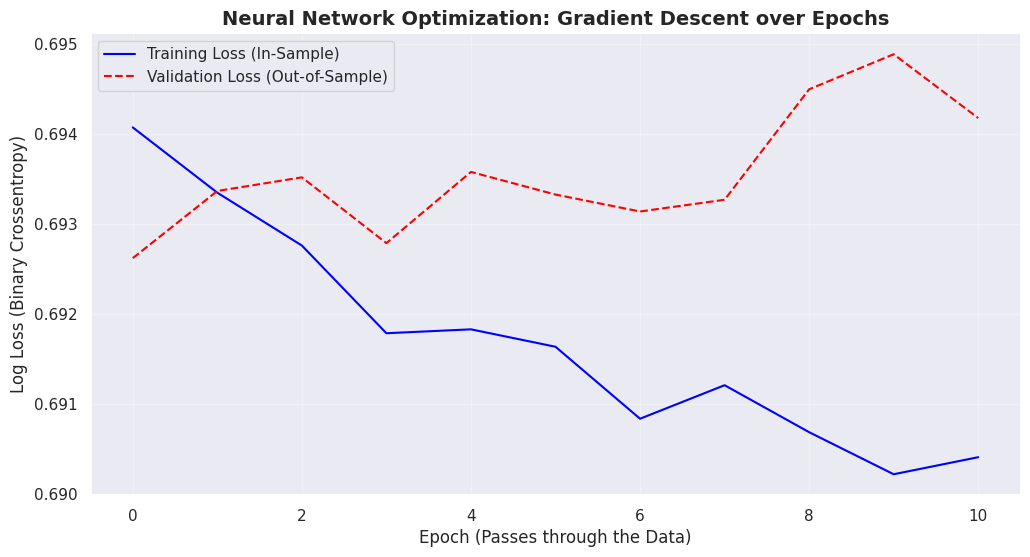


--- 5. FINAL DEEP LEARNING EVALUATION ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
 LSTM Out-of-Sample Accuracy: 50.99%
 LSTM Out-of-Sample Precision: 51.74%


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("--- 1. TENSOR RESHAPING (3D MATRIX EXPANSION) ---")
# Neural Networks (LSTMs) cannot read flat 2D spreadsheets.
# They require a 3D Tensor format: [Samples, Time_Steps, Features].
# Since our sliding window engineered the lags into the rows, our Time_Step is effectively 1.

X_train_lstm = np.array(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.array(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))

print(f" Training Tensor successfully reshaped to 3D: {X_train_lstm.shape}")


print("\n--- 2. LSTM NETWORK ARCHITECTURE ---")
# Building the deep learning architecture.

# Initialize the Sequential Neural Network
lstm_model = Sequential()

# Layer 1: LSTM Core
# 64 internal nodes, returning sequences if we add more LSTM layers, but False for a single layer.
lstm_model.add(LSTM(units=64, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

# Layer 2: Dropout Regularization
# We randomly turn off 30% of the neurons during training to mathematically force the network NOT to memorize the data (overfitting).
lstm_model.add(Dropout(0.3))

# Layer 3: Dense Output Node
# A single neuron with a Sigmoid activation function to squash the output between 0 (DOWN) and 1 (UP).
lstm_model.add(Dense(units=1, activation='sigmoid'))

# Compiling the Network using Gradient Descent (Adam Optimizer)
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(" LSTM Network Architecture successfully compiled.")


print("\n--- 3. DEEP LEARNING EXECUTION (EPOCH TRAINING) ---")
# We pass over the entire dataset 50 times.
# We also use 'EarlyStopping' to automatically halt training if the algorithm stops improving, saving time.

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training the model
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=50,                  # Number of passes through the data
    batch_size=32,              # How many days of data to process at once before updating weights
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stop],
    verbose=1
)


print("\n--- 4. VISUALIZING THE NEURAL GRADIENT DESCENT ---")
# We must plot the loss over the Epochs to prove the Neural Network actually learned,

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], color='blue', label='Training Loss (In-Sample)')
plt.plot(history.history['val_loss'], color='red', linestyle='--', label='Validation Loss (Out-of-Sample)')
plt.title('Neural Network Optimization: Gradient Descent over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch (Passes through the Data)', fontsize=12)
plt.ylabel('Log Loss (Binary Crossentropy)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- 5. FINAL DEEP LEARNING EVALUATION ---")
# Predicting probabilities and convert to binary signals (0 or 1)
lstm_probabilities = lstm_model.predict(X_test_lstm)
lstm_preds = (lstm_probabilities > 0.5).astype(int).flatten()

from sklearn.metrics import accuracy_score, precision_score
print(f" LSTM Out-of-Sample Accuracy: {accuracy_score(y_test, lstm_preds) * 100:.2f}%")
print(f" LSTM Out-of-Sample Precision: {precision_score(y_test, lstm_preds) * 100:.2f}%")

# Thank You